32
Finished
75
Finished
74
Finished
51
Finished
50
Finished
58
Finished
61
Finished
32
Finished
32
Finished
25
Finished
41
Finished
82
Finished
22
Finished
81
Finished
119
Finished
82
Finished
35
Finished
35
Finished
35
Finished
19
Finished
39
Finished
40
Finished
24
Finished
26
Finished
14
Finished
132
Finished
140
Finished
138
Finished
138
Finished
123
Finished
124
Finished
130
Finished
114
Finished
134
Finished
33
Finished
44
Finished
54
Finished
55
Finished
58
Finished
60
Finished
52
Finished
74
Finished
67
Finished
ndef= 301.4776119402985
ndef_var= 486.87636444642453
[-0.004, -0.005, -0.006, -0.007, -0.008, -0.009, -0.01, -0.02, -0.03, -0.04, -0.05, -0.06, -0.07, -0.08, -0.09, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0, -2.0, -3.0, -4.0, -5.0, -6.0, -7.0, -8.0, -9.0, -10.0, -20.0, -30.0, -40.0, -50.0, -60.0, -70.0, -80.0, -90.0, -100.0]


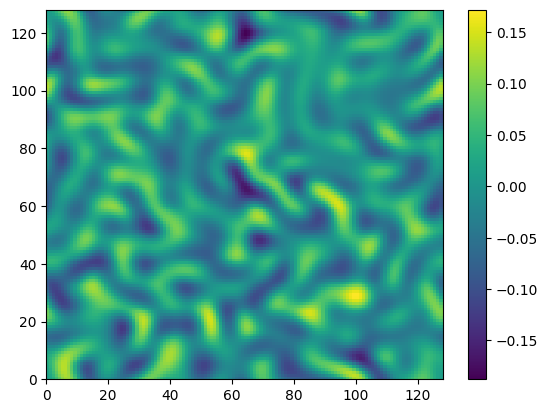

finished


In [1]:
import matplotlib.pyplot as plt
from scipy.io import *
import pandas as pd
import numpy as np

import fns






# compute the number of defects
def n_defect(nx,ny,dx,phi):
    
    '''
    Computation of energy spectrum and maximum wavenumber from vorticity field
    
    Inputs
    ------
    nx,ny : number of grid points in x and y direction
    w : vorticity field in physical spce (including periodic boundaries)
    
    Output
    ------
    en : energy spectrum computed from vorticity field
    n : maximum wavenumber
    '''
    
    epsilon = 1.0e-8

    kx = np.empty(nx)
    ky = np.empty(ny)
    
    kx[0:int(nx/2)] = np.float64(np.arange(0,int(nx/2))) *2*np.pi/(np.float64(nx)*dx)
    kx[int(nx/2):nx] = np.float64(np.arange(-int(nx/2),0))* 2*np.pi/(np.float64(nx)*dx)

    ky[0:ny] = kx[0:ny]
    
    kx[0] = epsilon
    ky[0] = epsilon
    kx, ky = np.meshgrid(kx, ky, indexing='ij')
    
    kk = np.sqrt(kx[:,:]**2 + ky[:,:]**2)
    kx2=kx[:,:]**2
    ky2=ky[:,:]**2
    

    n_defects=[]
    n_pdefects=[]
    n_ndefects=[]
    
    no_def=[]
    print(phi.shape[0])
    for i in range(phi.shape[0]):
        phi_t=phi[i,:].reshape(nx,nx)
        phi_ft=np.fft.fft2(phi_t)
        dyphi_ft=(1j*ky[:,:]* phi_ft)
        dxphi_ft=(1j*kx[:,:]* phi_ft)
        
        dxphi=np.real(np.fft.ifft2(dxphi_ft))
        dyphi=np.real(np.fft.ifft2(dyphi_ft))
        
        S11=0.5 * ((dyphi **2)-(dxphi)**2)
        S12= - dxphi * dyphi
        
        lattice_angle= fns.smoothening(S11,S12,64,dx,4)
        pd,nd,cs=fns.lattice_charge(lattice_angle,3.1)
        
        #pd,nd,charge=fns.lattice_charge(lattice_angle,3.1)
        pD,nD=fns.defect_anhilation(pd,nd,3)
        
        p_count=[]
        n_count=[]
        
        
        #for j in range(len(cs)):
       # 	if cs[j]>0:
        #		p_count.append(cs[j])
        #	else:
        #		n_count.append(cs[j])
        #n_defects.append(len(cs))
        #n_pdefects.append(len(p_count))
        #n_ndefects.append(len(n_count))
        
        no_def.append(len(pD)+len(nD))
        
        
	
	
    return no_def
    



# =======================
#  Load data
# =======================

idx       = [0]
#param_all = ['N_64_T_1e-5_con']
#param_all = ['N_64_T_5e-3_ext']
param_all = ['Turb_k1_.004','Turb_k1_.005','Turb_k1_.006','Turb_k1_.007','Turb_k1_.008','Turb_k1_.009','Turb_k1_.01','Turb_k1_.02','Turb_k1_.03','Turb_k1_.04','Turb_k1_.05','Turb_k1_.06','Turb_k1_.07','Turb_k1_.08','Turb_k1_.09','Turb_k1_.1','Turb_k1_.2','Turb_k1_.3','Turb_k1_.4','Turb_k1_.5','Turb_k1_.6','Turb_k1_.7','Turb_k1_.8','Turb_k1_.9','Turb_k1_1','Turb_k1_2','Turb_k1_3','Turb_k1_4','Turb_k1_5','Turb_k1_6','Turb_k1_7','Turb_k1_8','Turb_k1_9','Turb_k1_10','Turb_k1_20','Turb_k1_30','Turb_k1_40','Turb_k1_50'
,'Turb_k1_60','Turb_k1_70','Turb_k1_80','Turb_k1_90','Turb_k1_100']

N_plot = len(param_all)

# =======================
#  Measure epr
# =======================

k1_vec=[]
ndef_vec=[]
ndef_v_vec=[]
p_def_vec=[]
p_def_v_vec=[]
n_def_vec=[]
n_def_v_vec=[]

no_def=[]
for j in range(N_plot):
	param  = param_all[j]

	# Load parameters
	d_name          = param	
	data            = loadmat(d_name + '.mat')
	phi             = data['data_phi']
	psi             = data['data_psi']
	k               = float(data['kappa'])
	k1              = float(data['kappa1'])
	N               = int(data['Nx'])
	
	dx              =0.5

	numbdef=n_defect(N,N,dx,phi)
	
	
	ndef_m=np.mean(numbdef)
	ndef_v=np.var(numbdef)
	
	#p_def_m=np.mean(p_def)
	#p_def_v=np.var(p_def)
	
	#n_def_m=np.mean(n_def)
	#n_def_v=np.var(n_def)
	
	
	
	k1_vec.append(k1)
	ndef_vec.append(ndef_m)
	ndef_v_vec.append(ndef_v)
	
	#p_def_vec.append(p_def_m)
	#p_def_v_vec.append(p_def_v)
	
	#n_def_vec.append(n_def_m)
	#n_def_v_vec.append(n_def_v)
	
	#no_def.append(numbdef)
	
	print ('Finished')
	
print('ndef=',ndef_m)	
print('ndef_var=',ndef_v)
print(k1_vec)	
#weights = np.ones_like(eprsum)/float(len(eprsum))
#count, binss,p=plt.hist(eprsum,weights=weights,bins=10)

#creating table
data = {'k1':k1_vec,'def':ndef_vec ,'def_v':ndef_v_vec}
df = pd.DataFrame (data, columns = ['k1','def','def_v'])#
df.to_csv("Turb_full_defects.csv",)     

plt.pcolor(phi[0,:].reshape(N,N))
#plt.pcolor(epr,vmin=-epr.max(),vmax=epr.max())
plt.colorbar()
plt.show()

print("finished")
